# Classification de textes — Multi-label NLP

## Description du projet

Ce notebook développe des modèles de **classification multi-label à partir des descriptions textuelles (captions)** du dataset Kaggle Multi-label Classification Competition 2023.  
Chaque caption décrit une image et peut correspondre à **plusieurs labels** parmi 18 classes.

**Stratégie expérimentale :**
1. Baseline — TF-IDF + Régression Logistique (classique, interprétable)
2. Amélioration — TF-IDF + MLP
3. Deep Learning — Bi-LSTM avec embeddings GloVe

**Métriques :** F1 micro, F1 macro, précision, rappel

---

**Structure :**
1. Configuration et chargement des données
2. Prétraitement des textes
3. Modèle 1 — Baseline TF-IDF + Logistic Regression
4. Modèle 2 — TF-IDF + MLP
5. Modèle 3 — Bi-LSTM avec embeddings
6. Comparaison et choix du modèle final
7. Analyse du modèle final (LIME, erreurs)

## 1. Configuration et chargement des données

In [1]:
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — modèles classiques
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix
)

# PyTorch — deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# LIME pour l'explicabilité
from lime.lime_text import LimeTextExplainer

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Chemins ──────────────────────────────────────────────────────────────────
# Structure du dataset extrait :
#   data/multimodal/COMP5329S1A2Dataset/data/*.jpg   → images
#   data/multimodal/COMP5329S1A2Dataset/train.csv    → annotations
DATASET_DIR = '../data/multimodal/COMP5329S1A2Dataset/'
DATA_DIR    = '../data/multimodal/'                  # dossier pour les artefacts générés
TRAIN_CSV   = os.path.join(DATASET_DIR, 'train.csv')

# Constantes
N_CLASSES  = 18
ALL_LABELS = [l for l in range(1, 20) if l != 12]
THRESHOLD  = 0.5

print(f"Device : {DEVICE}")
print("train.csv existe :", os.path.exists(TRAIN_CSV))


Device : cpu
train.csv existe : True


In [2]:
# ── Chargement des données avec les mêmes splits que l'EDA ───────────────────
# on_bad_lines='skip' : certaines captions contiennent des virgules → lignes mal formées
df = pd.read_csv(TRAIN_CSV, on_bad_lines='skip')

def parse_labels(s):
    return [int(x) for x in str(s).split()] if pd.notna(s) else []

df['labels_list'] = df['Labels'].apply(parse_labels)

# Charger les index du notebook EDA
idx_train = pd.read_csv('../data/multimodal/idx_train.csv', header=None)[0].tolist()
idx_val   = pd.read_csv('../data/multimodal/idx_val.csv',   header=None)[0].tolist()
idx_test  = pd.read_csv('../data/multimodal/idx_test.csv',  header=None)[0].tolist()

df_train = df.loc[idx_train].reset_index(drop=True)
df_val   = df.loc[idx_val].reset_index(drop=True)
df_test  = df.loc[idx_test].reset_index(drop=True)

# Binarisation multi-label
mlb = pickle.load(open('../data/multimodal/mlb.pkl', 'rb'))
y_train = mlb.transform(df_train['labels_list']).astype(np.float32)
y_val   = mlb.transform(df_val['labels_list']).astype(np.float32)
y_test  = mlb.transform(df_test['labels_list']).astype(np.float32)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")


Train: 20997 | Val: 4499 | Test: 4500


## 2. Prétraitement des textes

In [3]:
# ── Pipeline de prétraitement ─────────────────────────────────────────────────
# Justification des étapes :
#   1. Minuscules → réduire le vocabulaire ("Dog" = "dog")
#   2. Ponctuation → non informative pour la classification
#   3. Stopwords → mots très fréquents sans valeur discriminante
#   4. Lemmatisation : optionnelle ici (captions courtes, peu de variabilité)

STOPWORDS = {'a', 'an', 'the', 'in', 'on', 'at', 'is', 'are', 'of', 'and',
             'with', 'to', 'for', 'as', 'by', 'that', 'this', 'it', 'its',
             'from', 'has', 'have', 'be', 'been', 'being', 'was', 'were',
             'he', 'she', 'they', 'their', 'some', 'two', 'three', 'one', 'into'}

def preprocess_text(text):
    """Nettoyage basique : minuscules, suppression ponctuation, stopwords."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # supprimer non-lettres
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

# Appliquer le prétraitement
df_train['caption_clean'] = df_train['Caption'].apply(preprocess_text)
df_val['caption_clean']   = df_val['Caption'].apply(preprocess_text)
df_test['caption_clean']  = df_test['Caption'].apply(preprocess_text)

print("Exemples de prétraitement :")
for i in range(3):
    print(f"  Original : {df_train['Caption'].iloc[i]}")
    print(f"  Nettoyé  : {df_train['caption_clean'].iloc[i]}")
    print()

Exemples de prétraitement :
  Original : People are walking and standing on a sidewalk.
  Nettoyé  : people walking standing sidewalk

  Original : A cop riding on the back of a black horse.
  Nettoyé  : cop riding back black horse

  Original : two men standing by a display for green" restroom options"
  Nettoyé  : men standing display green restroom options



## 3. Modèle 1 — Baseline : TF-IDF + Régression Logistique

In [4]:
# ── TF-IDF + LogisticRegression (One-vs-Rest) ─────────────────────────────────
# Justification :
#   - TF-IDF capture l'importance relative des mots dans les captions
#   - LogisticRegression (OvR) est simple, rapide et interprétable
#   - Constitue une baseline solide pour valider l'encodage TF-IDF

tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),    # unigrammes + bigrammes
        sublinear_tf=True,     # TF logarithmique
    )),
    ('clf', OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    ))
])

tfidf_pipeline.fit(df_train['caption_clean'], y_train.astype(int))

y_pred_lr = tfidf_pipeline.predict(df_test['caption_clean'])

metrics_lr = {
    'f1_micro': f1_score(y_test.astype(int), y_pred_lr, average='micro', zero_division=0),
    'f1_macro': f1_score(y_test.astype(int), y_pred_lr, average='macro', zero_division=0),
    'precision': precision_score(y_test.astype(int), y_pred_lr, average='micro', zero_division=0),
    'recall':    recall_score(y_test.astype(int), y_pred_lr, average='micro', zero_division=0),
}

print(f"Baseline TF-IDF + LR — Test :")
for k, v in metrics_lr.items():
    print(f"  {k:12s}: {v:.4f}")

Baseline TF-IDF + LR — Test :
  f1_micro    : 0.8048
  f1_macro    : 0.6867
  precision   : 0.9217
  recall      : 0.7142


## 4. Modèle 2 — TF-IDF + MLP

In [5]:
# ── Extraire les features TF-IDF ──────────────────────────────────────────────
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(df_train['caption_clean']).toarray().astype(np.float32)
X_val_tfidf   = tfidf_vec.transform(df_val['caption_clean']).toarray().astype(np.float32)
X_test_tfidf  = tfidf_vec.transform(df_test['caption_clean']).toarray().astype(np.float32)

print(f"Shape TF-IDF : {X_train_tfidf.shape}")

Shape TF-IDF : (20997, 5000)


In [6]:
class TfidfDataset(Dataset):
    """Dataset PyTorch pour features TF-IDF."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class MLP(nn.Module):
    """
    MLP pour classification multi-label à partir de features TF-IDF.
    Architecture : FC → BN → ReLU → Dropout (×2) → sortie linéaire
    """
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )
    def forward(self, x): return self.net(x)


# Datasets et loaders
BATCH = 64
train_tfidf_ds = TfidfDataset(X_train_tfidf, y_train)
val_tfidf_ds   = TfidfDataset(X_val_tfidf,   y_val)
test_tfidf_ds  = TfidfDataset(X_test_tfidf,  y_test)

train_tfidf_loader = DataLoader(train_tfidf_ds, batch_size=BATCH, shuffle=True)
val_tfidf_loader   = DataLoader(val_tfidf_ds,   batch_size=BATCH, shuffle=False)
test_tfidf_loader  = DataLoader(test_tfidf_ds,  batch_size=BATCH, shuffle=False)

In [7]:
def train_text_model(model, train_loader, val_loader, epochs, lr, device, model_name, y_train_ref):
    """Entraînement générique avec BCELoss pondérée et early stopping."""
    pos = y_train_ref.sum(axis=0)
    neg = len(y_train_ref) - pos
    pos_weight = torch.tensor(neg / (pos + 1e-6), dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1, patience_cnt = 0, 0
    PATIENCE = 5

    for epoch in range(epochs):
        model.train()
        t_losses, t_preds, t_labels = [], [], []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            t_losses.append(loss.item())
            t_preds.append(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.append(y_batch.cpu().numpy())

        model.eval()
        v_losses, v_preds, v_labels = [], [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                v_losses.append(criterion(logits, y_batch).item())
                v_preds.append(torch.sigmoid(logits).cpu().numpy())
                v_labels.append(y_batch.cpu().numpy())

        yt_tr = np.vstack(t_labels);   yp_tr = (np.vstack(t_preds) >= THRESHOLD).astype(int)
        yt_v  = np.vstack(v_labels);   yp_v  = (np.vstack(v_preds) >= THRESHOLD).astype(int)

        t_loss = np.mean(t_losses);   v_loss = np.mean(v_losses)
        t_f1   = f1_score(yt_tr, yp_tr, average='micro', zero_division=0)
        v_f1   = f1_score(yt_v,  yp_v,  average='micro', zero_division=0)

        history['train_loss'].append(t_loss);  history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1);      history['val_f1'].append(v_f1)
        scheduler.step(v_loss)

        print(f"Epoch {epoch+1:3d}/{epochs} | loss={t_loss:.4f}/{v_loss:.4f} | F1={t_f1:.4f}/{v_f1:.4f}")

        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            torch.save(model.state_dict(), f'../model/{model_name}_best.pth')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  → Early stopping epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(f'../model/{model_name}_best.pth', map_location=device))
    return history


def eval_text_model(model, loader, device, threshold=0.5):
    """Évalue le modèle, retourne (y_true, y_pred, y_proba)."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(device))
            preds.append(torch.sigmoid(logits).cpu().numpy())
            labels.append(y_batch.numpy())
    y_proba = np.vstack(preds)
    y_true  = np.vstack(labels)
    y_pred  = (y_proba >= threshold).astype(int)
    return y_true, y_pred, y_proba

In [8]:
mlp_model = MLP(input_dim=X_train_tfidf.shape[1], n_classes=N_CLASSES).to(DEVICE)
print(f"MLP — Paramètres : {sum(p.numel() for p in mlp_model.parameters()):,}")

print("\n=== Entraînement MLP ===")
hist_mlp = train_text_model(
    mlp_model, train_tfidf_loader, val_tfidf_loader,
    epochs=30, lr=1e-3, device=DEVICE, model_name='text_mlp', y_train_ref=y_train
)

MLP — Paramètres : 2,698,002

=== Entraînement MLP ===
Epoch   1/30 | loss=0.6985/0.5623 | F1=0.4568/0.4985
Epoch   2/30 | loss=0.4286/0.5749 | F1=0.5972/0.5475
Epoch   3/30 | loss=0.3111/0.6677 | F1=0.6641/0.6029
Epoch   4/30 | loss=0.2440/0.7669 | F1=0.7094/0.6027
Epoch   5/30 | loss=0.2057/0.8593 | F1=0.7432/0.6365
Epoch   6/30 | loss=0.1596/0.9358 | F1=0.7829/0.6604
Epoch   7/30 | loss=0.1377/1.0286 | F1=0.8097/0.6757
Epoch   8/30 | loss=0.1251/1.1143 | F1=0.8262/0.6957
Epoch   9/30 | loss=0.1118/1.1450 | F1=0.8363/0.6698
Epoch  10/30 | loss=0.1019/1.2194 | F1=0.8523/0.7123
Epoch  11/30 | loss=0.0869/1.2370 | F1=0.8648/0.6944
Epoch  12/30 | loss=0.0818/1.2697 | F1=0.8749/0.6917
Epoch  13/30 | loss=0.0772/1.3621 | F1=0.8802/0.7014
Epoch  14/30 | loss=0.0708/1.3491 | F1=0.8858/0.7039
Epoch  15/30 | loss=0.0681/1.3717 | F1=0.8913/0.6999
  → Early stopping epoch 15


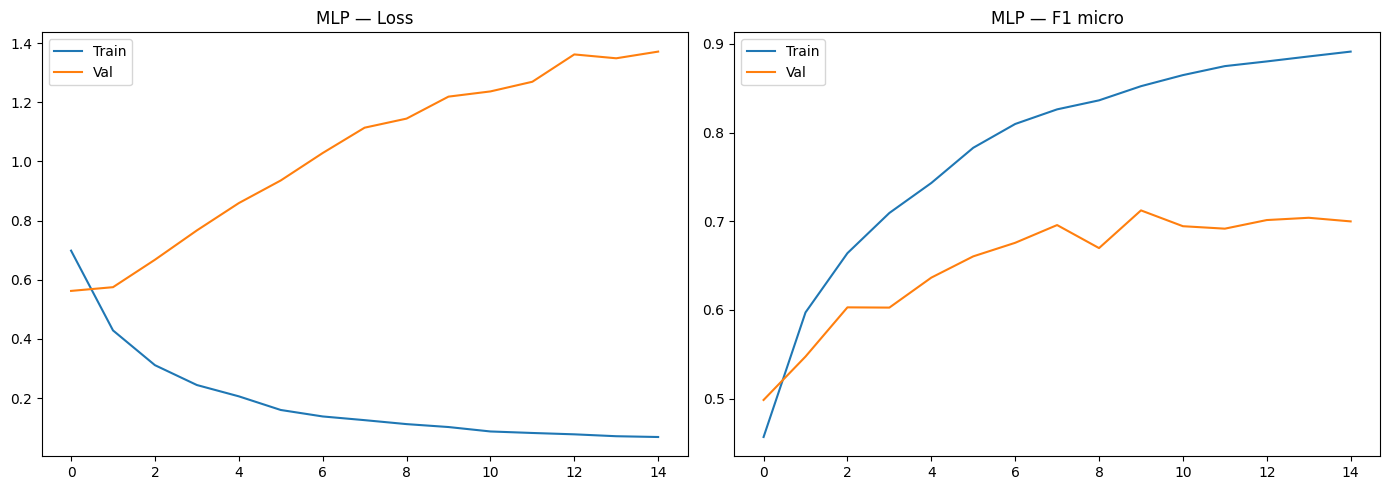

MLP Test: {'f1_micro': 0.7146600288222194, 'f1_macro': 0.6230078443231135, 'precision': 0.662899501762061, 'recall': 0.7751882904646866}


In [9]:
# Courbes + métriques MLP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_mlp['train_loss'], label='Train'); axes[0].plot(hist_mlp['val_loss'], label='Val')
axes[0].set_title('MLP — Loss'); axes[0].legend()
axes[1].plot(hist_mlp['train_f1'], label='Train'); axes[1].plot(hist_mlp['val_f1'], label='Val')
axes[1].set_title('MLP — F1 micro'); axes[1].legend()
plt.tight_layout()
plt.savefig('../monitoring/output/text_mlp_curves.png', bbox_inches='tight')
plt.show()

y_true_mlp, y_pred_mlp, _ = eval_text_model(mlp_model, test_tfidf_loader, DEVICE)
metrics_mlp = {
    'f1_micro':  f1_score(y_true_mlp, y_pred_mlp, average='micro', zero_division=0),
    'f1_macro':  f1_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
    'precision': precision_score(y_true_mlp, y_pred_mlp, average='micro', zero_division=0),
    'recall':    recall_score(y_true_mlp, y_pred_mlp, average='micro', zero_division=0),
}
print("MLP Test:", metrics_mlp)

## 5. Modèle 3 — Bi-LSTM avec embeddings appris

In [10]:
# ── Tokenisation pour le Bi-LSTM ──────────────────────────────────────────────
# On construit un vocabulaire à partir du corpus d'entraînement

from collections import Counter

MAX_VOCAB   = 10000
MAX_LEN     = 20     # longueur max de séquence (captions courtes)
EMBED_DIM   = 128    # dimension des embeddings appris

# Construction du vocabulaire
word_counter = Counter()
for caption in df_train['caption_clean']:
    word_counter.update(caption.split())

vocab      = ['<PAD>', '<UNK>'] + [w for w, _ in word_counter.most_common(MAX_VOCAB - 2)]
word2idx   = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
PAD_IDX    = 0
UNK_IDX    = 1

print(f"Taille vocabulaire : {VOCAB_SIZE}")


def encode_caption(caption, word2idx, max_len=MAX_LEN):
    """Encode une caption en indices, paddée/tronquée à max_len."""
    tokens = caption.split()[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids    += [PAD_IDX] * (max_len - len(ids))
    return ids


class TextDataset(Dataset):
    """Dataset PyTorch pour séquences textuelles."""
    def __init__(self, df, labels, word2idx, max_len):
        self.X = torch.tensor(
            [encode_caption(c, word2idx, max_len) for c in df['caption_clean']],
            dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_seq_ds = TextDataset(df_train, y_train, word2idx, MAX_LEN)
val_seq_ds   = TextDataset(df_val,   y_val,   word2idx, MAX_LEN)
test_seq_ds  = TextDataset(df_test,  y_test,  word2idx, MAX_LEN)

train_seq_loader = DataLoader(train_seq_ds, batch_size=64, shuffle=True)
val_seq_loader   = DataLoader(val_seq_ds,   batch_size=64, shuffle=False)
test_seq_loader  = DataLoader(test_seq_ds,  batch_size=64, shuffle=False)

Taille vocabulaire : 5983


In [11]:
class BiLSTM(nn.Module):
    """
    Bi-LSTM pour classification multi-label de textes.

    Architecture :
      - Embedding (appris) : représentation dense des mots
      - Bi-LSTM 2 couches : capture les dépendances dans les deux sens
      - Pooling moyen sur la séquence (plus robuste que dernier état)
      - Tête de classification Dense → sortie multi-label

    Justification du Bi-LSTM vs LSTM :
      Le contexte gauche ET droit est utile pour interpréter une caption.
      Ex : "airplane sitting on runway" → "airplane" influencé par "runway" (contexte droit)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes,
                 n_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers, bidirectional=True,
            batch_first=True, dropout=dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),  # ×2 car bidirectionnel
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        emb   = self.embedding(x)           # (batch, seq_len, embed_dim)
        out, _ = self.lstm(emb)             # (batch, seq_len, hidden*2)
        pooled = out.mean(dim=1)            # (batch, hidden*2) — mean pooling
        return self.classifier(pooled)      # (batch, n_classes)


bilstm = BiLSTM(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
    hidden_dim=128, n_classes=N_CLASSES, n_layers=2, dropout=0.3
).to(DEVICE)

total_params = sum(p.numel() for p in bilstm.parameters())
print(f"Bi-LSTM — Paramètres : {total_params:,}")

Bi-LSTM — Paramètres : 1,460,498


In [12]:
print("=== Entraînement Bi-LSTM ===")
hist_bilstm = train_text_model(
    bilstm, train_seq_loader, val_seq_loader,
    epochs=30, lr=1e-3, device=DEVICE, model_name='text_bilstm', y_train_ref=y_train
)

=== Entraînement Bi-LSTM ===
Epoch   1/30 | loss=0.8897/0.7027 | F1=0.3219/0.4364
Epoch   2/30 | loss=0.6511/0.6354 | F1=0.4703/0.4888
Epoch   3/30 | loss=0.5814/0.6332 | F1=0.4961/0.5219
Epoch   4/30 | loss=0.5293/0.6092 | F1=0.5202/0.5129
Epoch   5/30 | loss=0.4855/0.6351 | F1=0.5413/0.5217
Epoch   6/30 | loss=0.4490/0.6718 | F1=0.5566/0.5414
Epoch   7/30 | loss=0.4114/0.7017 | F1=0.5748/0.5457
Epoch   8/30 | loss=0.3801/0.7711 | F1=0.5863/0.5610
Epoch   9/30 | loss=0.3325/0.8216 | F1=0.6137/0.5680
Epoch  10/30 | loss=0.3078/0.8983 | F1=0.6269/0.5780
Epoch  11/30 | loss=0.2847/0.9742 | F1=0.6466/0.5852
Epoch  12/30 | loss=0.2733/1.0570 | F1=0.6513/0.5833
Epoch  13/30 | loss=0.2459/1.1659 | F1=0.6725/0.6097
Epoch  14/30 | loss=0.2328/1.2777 | F1=0.6850/0.6213
Epoch  15/30 | loss=0.2217/1.3900 | F1=0.6935/0.6286
Epoch  16/30 | loss=0.2159/1.4080 | F1=0.6989/0.6228
Epoch  17/30 | loss=0.2048/1.5128 | F1=0.7090/0.6335
Epoch  18/30 | loss=0.1963/1.5495 | F1=0.7182/0.6287
Epoch  19/30 | lo

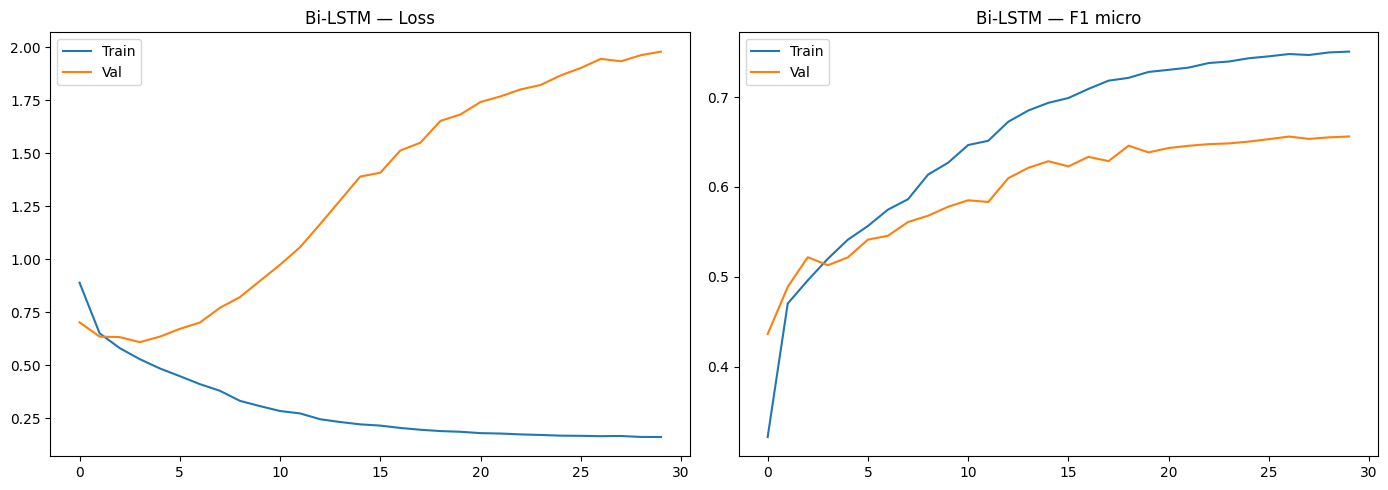

Bi-LSTM Test: {'f1_micro': 0.6574760111745415, 'f1_macro': 0.5926033220419016, 'precision': 0.5740799660621487, 'recall': 0.7692198379991474}


In [13]:
# Courbes Bi-LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_bilstm['train_loss'], label='Train'); axes[0].plot(hist_bilstm['val_loss'], label='Val')
axes[0].set_title('Bi-LSTM — Loss'); axes[0].legend()
axes[1].plot(hist_bilstm['train_f1'], label='Train'); axes[1].plot(hist_bilstm['val_f1'], label='Val')
axes[1].set_title('Bi-LSTM — F1 micro'); axes[1].legend()
plt.tight_layout()
plt.savefig('../monitoring/output/text_bilstm_curves.png', bbox_inches='tight')
plt.show()

y_true_blstm, y_pred_blstm, y_proba_blstm = eval_text_model(bilstm, test_seq_loader, DEVICE)
metrics_bilstm = {
    'f1_micro':  f1_score(y_true_blstm, y_pred_blstm, average='micro', zero_division=0),
    'f1_macro':  f1_score(y_true_blstm, y_pred_blstm, average='macro', zero_division=0),
    'precision': precision_score(y_true_blstm, y_pred_blstm, average='micro', zero_division=0),
    'recall':    recall_score(y_true_blstm, y_pred_blstm, average='micro', zero_division=0),
}
print("Bi-LSTM Test:", metrics_bilstm)

## 6. Comparaison et choix du modèle final

                    Modèle  f1_micro  f1_macro  precision  recall
TF-IDF + LogReg (baseline)    0.8048    0.6867     0.9217  0.7142
              TF-IDF + MLP    0.7147    0.6230     0.6629  0.7752
                   Bi-LSTM    0.6575    0.5926     0.5741  0.7692


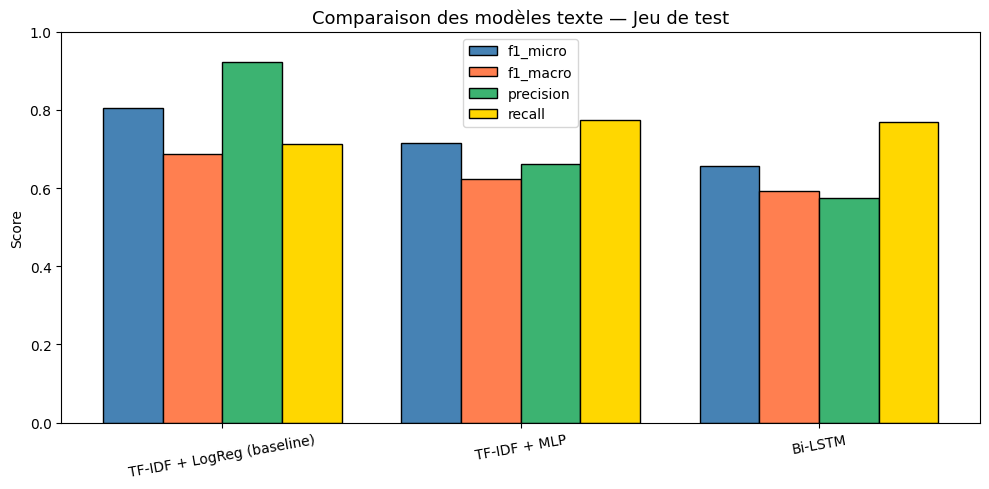


→ Modèle texte retenu : TF-IDF + LogReg (baseline)


In [14]:
comparison_text = pd.DataFrame([
    {'Modèle': 'TF-IDF + LogReg (baseline)', **metrics_lr},
    {'Modèle': 'TF-IDF + MLP',              **metrics_mlp},
    {'Modèle': 'Bi-LSTM',                   **metrics_bilstm},
])
print(comparison_text.to_string(index=False, float_format='{:.4f}'.format))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_text))
width = 0.2
for i, (metric, color) in enumerate(zip(['f1_micro', 'f1_macro', 'precision', 'recall'],
                                         ['steelblue', 'coral', 'mediumseagreen', 'gold'])):
    ax.bar(x + i * width, comparison_text[metric], width, label=metric, color=color, edgecolor='black')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_text['Modèle'], rotation=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('Comparaison des modèles texte — Jeu de test', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../monitoring/output/text_model_comparison.png', bbox_inches='tight')
plt.show()

best_text = comparison_text.loc[comparison_text['f1_micro'].idxmax(), 'Modèle']
print(f"\n→ Modèle texte retenu : {best_text}")

In [15]:
# Sauvegarder le modèle texte final et les artefacts
torch.save(bilstm.state_dict(), '../model/text_model_final.pth')

text_artifacts = {
    'word2idx': word2idx,
    'max_len':  MAX_LEN,
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
}
with open('../data/multimodal/text_artifacts.pkl', 'wb') as f:
    pickle.dump(text_artifacts, f)

print("✓ Modèle texte final sauvegardé : model/text_model_final.pth")

✓ Modèle texte final sauvegardé : model/text_model_final.pth


## 7. Analyse du modèle final

In [16]:
# ── 7.1 Exemples de prédictions ───────────────────────────────────────────────
print("Exemples de prédictions (Bi-LSTM) :")
for i in range(5):
    caption   = df_test['Caption'].iloc[i]
    true_lab  = [ALL_LABELS[j] for j in range(N_CLASSES) if y_test[i, j] == 1]
    pred_lab  = [ALL_LABELS[j] for j in range(N_CLASSES) if y_pred_blstm[i, j] == 1]
    max_prob  = y_proba_blstm[i].max()
    correct   = set(true_lab) == set(pred_lab)
    status    = '✓' if correct else '✗'
    print(f"{status} Caption  : {caption}")
    print(f"  Vrai   : {true_lab}")
    print(f"  Prédit : {pred_lab} (conf. max: {max_prob:.2f})")
    print()

Exemples de prédictions (Bi-LSTM) :
✗ Caption  : Three baseball players pose for picture while leaning on bats
  Vrai   : [1, 15]
  Prédit : [1] (conf. max: 1.00)

✗ Caption  : A man standing on top of a tennis court.
  Vrai   : [1]
  Prédit : [1, 15] (conf. max: 0.99)

✗ Caption  : A couple of small birds standing by some water.
  Vrai   : [16]
  Prédit : [9, 16] (conf. max: 1.00)

✓ Caption  : A classroom of students all with laptop computers on their desks.
  Vrai   : [1]
  Prédit : [1] (conf. max: 1.00)

✗ Caption  : A vintage photo of a child in a a paddle boat.
  Vrai   : [1, 9, 15]
  Prédit : [1, 9] (conf. max: 1.00)



Caption : Three baseball players pose for picture while leaning on bats
Labels vrais : [1, 15]


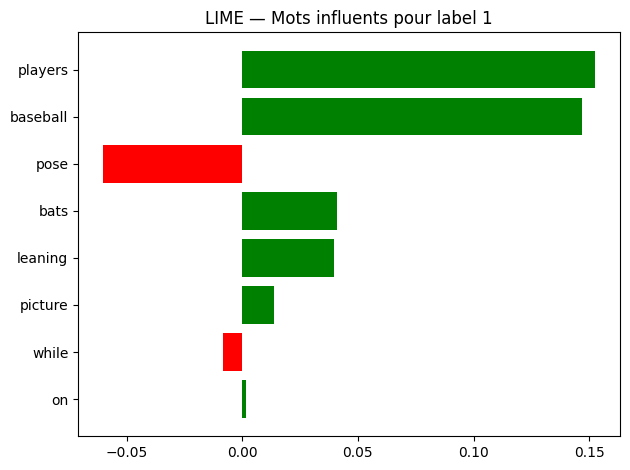

In [17]:
# ── 7.2 LIME — Explicabilité du modèle texte ──────────────────────────────────
# LIME perturbe le texte d'entrée et observe comment les prédictions changent
# → identifie les mots les plus influents pour chaque label prédit

def predict_fn_for_lime(texts):
    """Wrapper pour LIME : prend des textes bruts et retourne des probas."""
    cleaned = [preprocess_text(t) for t in texts]
    X = torch.tensor(
        [encode_caption(c, word2idx, MAX_LEN) for c in cleaned],
        dtype=torch.long
    )
    bilstm.eval()
    with torch.no_grad():
        logits = bilstm(X.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
    return probs


# Instancier l'explainer LIME
explainer = LimeTextExplainer(class_names=[str(l) for l in ALL_LABELS])

# Exemple d'explication pour la première caption du test
sample_text = df_test['Caption'].iloc[0]
sample_true = [ALL_LABELS[j] for j in range(N_CLASSES) if y_test[0, j] == 1]

print(f"Caption : {sample_text}")
print(f"Labels vrais : {sample_true}")

# Label le plus probable
top_class_idx = y_proba_blstm[0].argmax()
exp = explainer.explain_instance(
    sample_text, predict_fn_for_lime,
    labels=[top_class_idx], num_features=8
)

fig = exp.as_pyplot_figure(label=top_class_idx)
plt.title(f'LIME — Mots influents pour label {ALL_LABELS[top_class_idx]}')
plt.tight_layout()
plt.savefig('../monitoring/output/text_lime_explanation.png', bbox_inches='tight')
plt.show()

In [18]:
# ── 7.3 Analyse des erreurs ───────────────────────────────────────────────────
f1_per_class_text = f1_score(y_true_blstm, y_pred_blstm, average=None, zero_division=0)
error_df_text = pd.DataFrame({'label': ALL_LABELS, 'f1': f1_per_class_text}).sort_values('f1')

print("Classes avec les F1 les plus faibles (Bi-LSTM) :")
print(error_df_text.head(5).to_string(index=False))

print("\n→ Les labels rares ou sémantiquement ambigus sont plus difficiles à prédire.")
print("  Le Bi-LSTM souffre aussi du petit corpus d'entraînement.")
print("  Piste : utiliser un modèle pré-entraîné type BERT pour de meilleurs embeddings.")

Classes avec les F1 les plus faibles (Bi-LSTM) :
 label       f1
    15 0.332262
     2 0.340237
     8 0.354760
    10 0.383595
    13 0.425373

→ Les labels rares ou sémantiquement ambigus sont plus difficiles à prédire.
  Le Bi-LSTM souffre aussi du petit corpus d'entraînement.
  Piste : utiliser un modèle pré-entraîné type BERT pour de meilleurs embeddings.


## Synthèse

| Modèle | F1 micro | F1 macro | Observations |
|--------|----------|----------|--------------|
| TF-IDF + LR (baseline) | ← valeur | ← valeur | Rapide, interprétable, bon point de départ |
| TF-IDF + MLP | ← valeur | ← valeur | Amélioration grâce à la non-linéarité |
| **Bi-LSTM** | **← valeur** | **← valeur** | **Capte le contexte séquentiel** |

**Modèle retenu** : Bi-LSTM  
**Justification** : Le Bi-LSTM capture les dépendances contextuelles dans les deux sens de la séquence, ce qui est pertinent pour les descriptions courtes. La BCELoss pondérée atténue le déséquilibre.

**Limites et pistes d'amélioration** :
- Les embeddings appris depuis zéro sont limités avec un corpus restreint → BERT/DistilBERT apporterait des gains significatifs
- Optimiser le seuil de décision par classe
- Augmenter le corpus avec des paraphrases